CaO-MgO

ref - Wu, P., Eriksson, G., Pelton, A.D., 1993. Critical Evaluation and Optimization of the Thermodynamic Properties and Phase Diagrams of the CaO–FeO, CaO–MgO, CaO–MnO, FeO–MgO, FeO–MnO, and MgO–MnO Systems. Journal of the American Ceramic Society 76, 2065–2075. https://doi.org/10.1111/j.1151-2916.1993.tb08334.x

# Solid

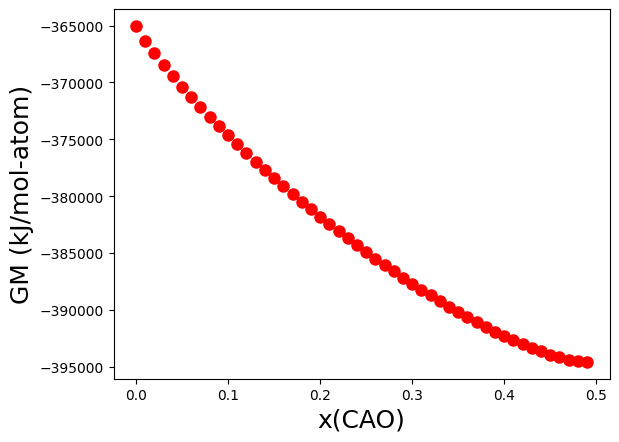

In [1]:
from pycalphad import Database, equilibrium, variables as v
import numpy as np
import matplotlib.pyplot as plt

dbf = Database("CaO-MgO.xml")
comps = ["CA", "MG", "O"]
phases = ["SOLID"]
conds = {
    v.N: 1,
    v.P: 101325,
    v.T: 1800,
    v.X("CA"): (0.0001, 0.49999, 0.01),
    v.X("O"): (0.5),
}

eq_1 = equilibrium(
    dbf,
    comps,
    phases,
    conds,
    verbose=False,
    calc_opts={"pdens": 2000},
    output=["SM", "HM", "G"],
)

comp_Ca = np.squeeze(eq_1.X.sel(component="CA").values)
X_Ca = np.array([i[0] for i in comp_Ca])

CalcGM = np.squeeze(eq_1.GM.values)
ax = plt.gca()
ax.plot(X_Ca, CalcGM, "ro", ms=8, label="PyCalphad")
ax.set_ylabel("GM (kJ/mol-atom)", fontsize=18)
ax.set_xlabel("x(CAO)", fontsize=18)
plt.show()

In [ ]:
# import pandas as pd

# df = pd.DataFrame({"X_Ca": X_Ca, "CalcGM": CalcGM})

# output_path = "CaO_MgO_1800K_solid_PyCalphad.xlsx"
# df.to_excel(output_path, index=False)
# print(f"Save data to: {output_path}")

# Liquid

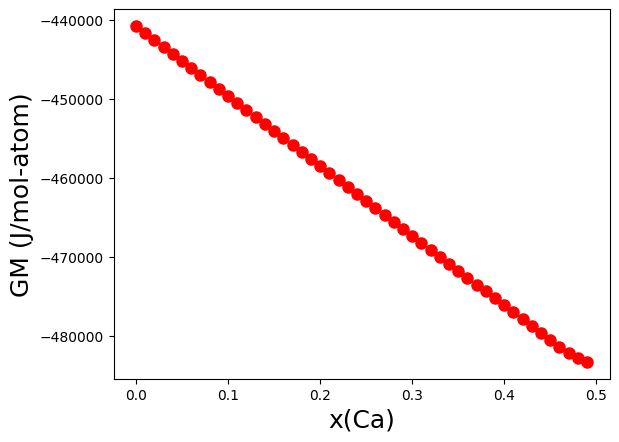

In [2]:
from pycalphad import Database, equilibrium, variables as v
import numpy as np
import matplotlib.pyplot as plt

from pycalphad.models.model_mqmqa import ModelMQMQA

dbf = Database("CaO-MgO.xml")
comps = ["CA", "MG", "O"]
phases = ["LIQUID"]
conds = {
    v.N: 1,
    v.P: 101325,
    v.T: 3000,
    v.X("CA"): (0.0001, 0.49999, 0.01),
    v.X("O"): (0.5),
}

eq_2 = equilibrium(
    dbf,
    comps,
    phases,
    conds,
    verbose=False,
    model={"LIQUID": ModelMQMQA},
    calc_opts={"pdens": 2000},
    output=["SM", "HM", "G"],
)

comp_Ca = np.squeeze(eq_2.X.sel(component="CA").values)
X_Ca = np.arange(0.0001, 0.49999, 0.01)
CalcGM = np.squeeze(eq_2.GM.values)
ax = plt.gca()
ax.plot(X_Ca, CalcGM, "ro", ms=8, label="PyCalphad")
ax.set_ylabel("GM (J/mol-atom)", fontsize=18)
ax.set_xlabel("x(Ca)", fontsize=18)
plt.show()